# 2025 FanGraphs Hit Rates per PA and per Hit

This notebook uses the local `mlbstatscraping` FanGraphs scraper to look at how often hitters recorded singles, doubles, triples, and home runs per plate appearance in 2025, then asks what share of each player's hits came from each hit type.

The core idea is simple: a counting stat tells us how many events happened, while a rate stat divides those events by a player's opportunities. `per_PA` uses plate appearances as the denominator; `per_H` uses total hits as the denominator.

## Imports

The path helper lets this notebook work whether it is launched from the repository root or from the `examples` folder.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if (repo_root / "src").exists():
    sys.path.insert(0, str(repo_root / "src"))
elif (repo_root.parent / "src").exists():
    sys.path.insert(0, str(repo_root.parent / "src"))

import mlbstatscraping as ss

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.facecolor": "white", "axes.linewidth": 1.1})
pd.set_option("display.max_columns", 100)

## Scrape 2025 Hitting Data

`qual=0` is already baked into the scraper, so FanGraphs returns all players rather than only qualified hitters.

In [2]:
YEAR = "2025"

raw = ss.get_fangraphs_data("hitting", [YEAR])
raw.shape

(1470, 28)

Take a quick look at the columns we need. The scraper already includes `H`, `1B`, `2B`, `3B`, `HR`, and `PA`.

In [3]:
events = ["1B", "2B", "3B", "HR"]
display_columns = ["Name", "Team", "Season", "PA", "H", *events]

raw.loc[:, display_columns].head(10)

,Name,Team,Season,PA,H,1B,2B,3B,HR
0,Francisco Lindor,NYM,2025,732.0,172.0,106.0,35.0,0.0,31.0
1,Rafael Devers,- - -,2025,729.0,153.0,85.0,33.0,0.0,35.0
2,Shohei Ohtani,LAD,2025,727.0,172.0,83.0,25.0,9.0,55.0
3,Matt Olson,ATL,2025,724.0,170.0,98.0,41.0,2.0,29.0
4,Kyle Schwarber,PHI,2025,724.0,145.0,64.0,23.0,2.0,56.0
5,Geraldo Perdomo,ARI,2025,720.0,173.0,115.0,33.0,5.0,20.0
6,Juan Soto,NYM,2025,715.0,152.0,88.0,20.0,1.0,43.0
7,Julio Rodriguez,SEA,2025,710.0,174.0,107.0,31.0,4.0,32.0
8,Pete Alonso,NYM,2025,709.0,170.0,90.0,41.0,1.0,38.0
9,Randy Arozarena,SEA,2025,709.0,146.0,86.0,32.0,1.0,27.0


## Build Rate Stats

A player's singles rate is `1B / PA`, doubles rate is `2B / PA`, and so on. We filter to `PA > 0` only to avoid dividing by zero.

In [4]:
needed_columns = ["Name", "Team", "Season", "Age", "G", "PA", "H", *events]
rates = raw.loc[:, needed_columns].copy()

for column in ["PA", "H", *events]:
    rates[column] = pd.to_numeric(rates[column], errors="coerce")

rates = rates.loc[rates["PA"] > 0].reset_index(drop=True)

for event in events:
    rates[f"{event}_per_PA"] = rates[event] / rates["PA"]

rate_columns = [f"{event}_per_PA" for event in events]
rates.loc[:, ["Name", "Team", "PA", "H", *events, *rate_columns]].head(10)

,Name,Team,PA,H,1B,2B,3B,HR,1B_per_PA,2B_per_PA,3B_per_PA,HR_per_PA
0,Francisco Lindor,NYM,732.0,172.0,106.0,35.0,0.0,31.0,0.144809,0.047814,0.000000,0.042350
1,Rafael Devers,- - -,729.0,153.0,85.0,33.0,0.0,35.0,0.116598,0.045267,0.000000,0.048011
2,Shohei Ohtani,LAD,727.0,172.0,83.0,25.0,9.0,55.0,0.114168,0.034388,0.012380,0.075653
3,Matt Olson,ATL,724.0,170.0,98.0,41.0,2.0,29.0,0.135359,0.056630,0.002762,0.040055
4,Kyle Schwarber,PHI,724.0,145.0,64.0,23.0,2.0,56.0,0.088398,0.031768,0.002762,0.077348
5,Geraldo Perdomo,ARI,720.0,173.0,115.0,33.0,5.0,20.0,0.159722,0.045833,0.006944,0.027778
6,Juan Soto,NYM,715.0,152.0,88.0,20.0,1.0,43.0,0.123077,0.027972,0.001399,0.060140
7,Julio Rodriguez,SEA,710.0,174.0,107.0,31.0,4.0,32.0,0.150704,0.043662,0.005634,0.045070
8,Pete Alonso,NYM,709.0,170.0,90.0,41.0,1.0,38.0,0.126939,0.057828,0.001410,0.053597
9,Randy Arozarena,SEA,709.0,146.0,86.0,32.0,1.0,27.0,0.121298,0.045134,0.001410,0.038082


## Build Hit Mix Stats

`per_H` changes the question. Instead of asking how often the player produced each event per plate appearance, it asks what share of the player's hits were singles, doubles, triples, or homers. We filter these examples to players with `H > 0` to avoid dividing by zero.

In [5]:
for event in events:
    rates[f"{event}_per_H"] = rates[event] / rates["H"].where(rates["H"] > 0)

hit_rate_columns = [f"{event}_per_H" for event in events]
hit_mix = rates.loc[rates["H"] > 0].copy()

hit_mix.loc[:, ["Name", "Team", "PA", "H", *events, *hit_rate_columns]].head(10)

,Name,Team,PA,H,1B,2B,3B,HR,1B_per_H,2B_per_H,3B_per_H,HR_per_H
0,Francisco Lindor,NYM,732.0,172.0,106.0,35.0,0.0,31.0,0.616279,0.203488,0.000000,0.180233
1,Rafael Devers,- - -,729.0,153.0,85.0,33.0,0.0,35.0,0.555556,0.215686,0.000000,0.228758
2,Shohei Ohtani,LAD,727.0,172.0,83.0,25.0,9.0,55.0,0.482558,0.145349,0.052326,0.319767
3,Matt Olson,ATL,724.0,170.0,98.0,41.0,2.0,29.0,0.576471,0.241176,0.011765,0.170588
4,Kyle Schwarber,PHI,724.0,145.0,64.0,23.0,2.0,56.0,0.441379,0.158621,0.013793,0.386207
5,Geraldo Perdomo,ARI,720.0,173.0,115.0,33.0,5.0,20.0,0.664740,0.190751,0.028902,0.115607
6,Juan Soto,NYM,715.0,152.0,88.0,20.0,1.0,43.0,0.578947,0.131579,0.006579,0.282895
7,Julio Rodriguez,SEA,710.0,174.0,107.0,31.0,4.0,32.0,0.614943,0.178161,0.022989,0.183908
8,Pete Alonso,NYM,709.0,170.0,90.0,41.0,1.0,38.0,0.529412,0.241176,0.005882,0.223529
9,Randy Arozarena,SEA,709.0,146.0,86.0,32.0,1.0,27.0,0.589041,0.219178,0.006849,0.184932


## Leaguewide Event Rates

For a leaguewide rate, sum all events and divide by all plate appearances. This weights a 650 PA regular more than a 12 PA call-up, which is usually what we want for a league environment measure.

In [6]:
league_rates = (
    rates.loc[:, events]
    .sum()
    .div(rates["PA"].sum())
    .rename("event_per_PA")
    .to_frame()
)
league_rates["PA_per_event"] = 1 / league_rates["event_per_PA"]
league_rates

,event_per_PA,PA_per_event
1B,0.142763,7.004595
2B,0.042340,23.618464
3B,0.003433,291.281847
HR,0.030887,32.376106


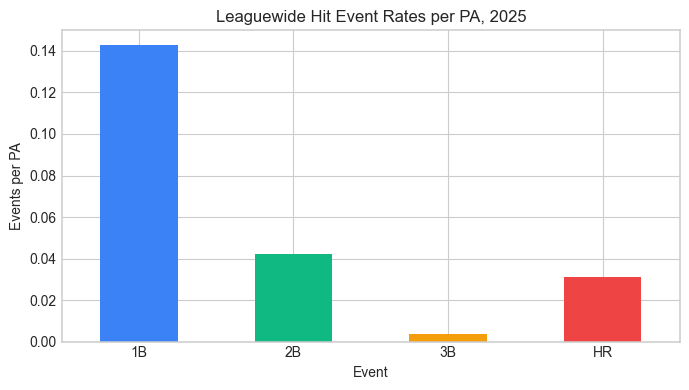

In [7]:
axis = league_rates["event_per_PA"].plot(
    kind="bar",
    figsize=(7, 4),
    color=["#3B82F6", "#10B981", "#F59E0B", "#EF4444"],
)
axis.set_title(f"Leaguewide Hit Event Rates per PA, {YEAR}")
axis.set_xlabel("Event")
axis.set_ylabel("Events per PA")
axis.tick_params(axis="x", rotation=0)
plt.tight_layout()

## Leaguewide Hit Mix

The same summed-events logic works for hit mix: sum each hit type, then divide by total hits. These shares should add up to about 1 because singles, doubles, triples, and homers partition hits.

In [8]:
league_hit_mix = (
    rates.loc[:, events]
    .sum()
    .div(rates["H"].sum())
    .rename("share_of_hits")
    .to_frame()
)
league_hit_mix

,share_of_hits
1B,0.650630
2B,0.192959
3B,0.015646
HR,0.140764


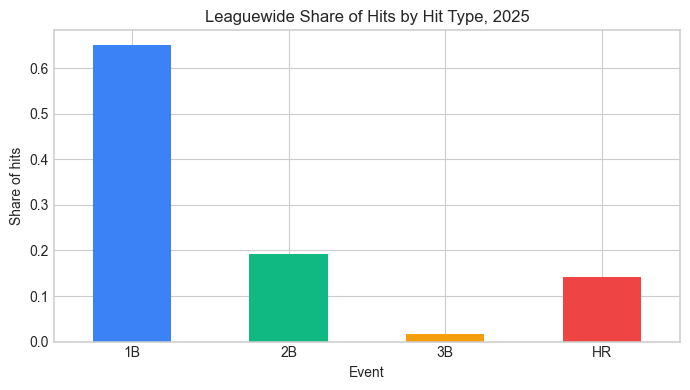

In [9]:
axis = league_hit_mix["share_of_hits"].plot(
    kind="bar",
    figsize=(7, 4),
    color=["#3B82F6", "#10B981", "#F59E0B", "#EF4444"],
)
axis.set_title(f"Leaguewide Share of Hits by Hit Type, {YEAR}")
axis.set_xlabel("Event")
axis.set_ylabel("Share of hits")
axis.tick_params(axis="x", rotation=0)
plt.tight_layout()

## Player Distributions

These histograms use every player with at least one PA. Expect many zeros, especially for triples and home runs. That is part of the lesson: tiny samples make rate stats noisy.

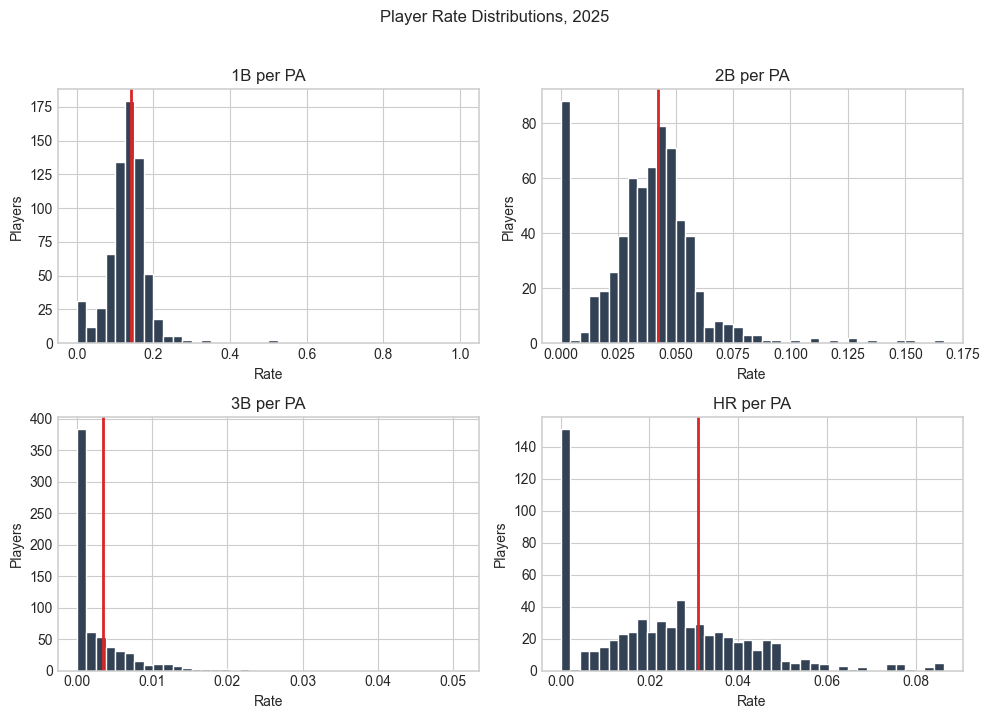

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=False)
axes = axes.ravel()

for axis, event, rate_column in zip(axes, events, rate_columns):
    axis.hist(rates[rate_column], bins=40, color="#334155", edgecolor="white")
    axis.axvline(league_rates.loc[event, "event_per_PA"], color="#DC2626", linewidth=2)
    axis.set_title(f"{event} per PA")
    axis.set_xlabel("Rate")
    axis.set_ylabel("Players")

fig.suptitle(f"Player Rate Distributions, {YEAR}", y=1.02)
fig.tight_layout()

## Player Hit Mix Distributions

These histograms use players with at least one hit. The vertical line is the leaguewide share of hits for that event.

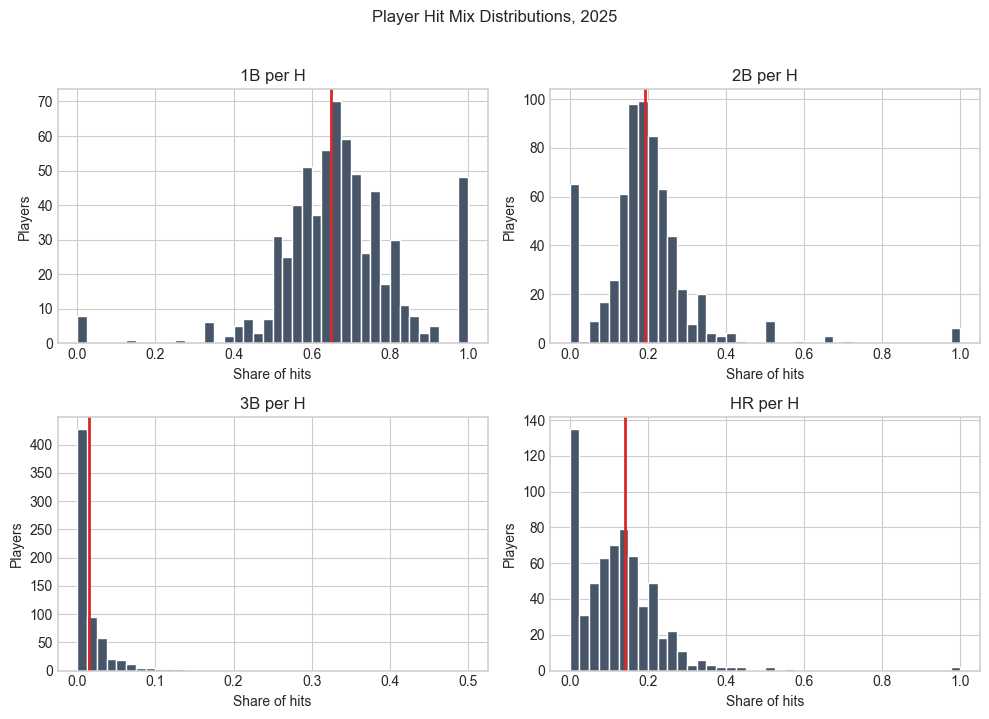

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=False)
axes = axes.ravel()

for axis, event, hit_rate_column in zip(axes, events, hit_rate_columns):
    axis.hist(hit_mix[hit_rate_column], bins=40, color="#475569", edgecolor="white")
    axis.axvline(league_hit_mix.loc[event, "share_of_hits"], color="#DC2626", linewidth=2)
    axis.set_title(f"{event} per H")
    axis.set_xlabel("Share of hits")
    axis.set_ylabel("Players")

fig.suptitle(f"Player Hit Mix Distributions, {YEAR}", y=1.02)
fig.tight_layout()

## Regular-Playing-Time Leaderboards

For leaderboards, a minimum PA cutoff makes the comparison more meaningful. The rate calculations above still include all players; this cutoff is only for display.

In [12]:
MIN_PA_FOR_LEADERBOARDS = 250
leader_pool = rates.loc[rates["PA"] >= MIN_PA_FOR_LEADERBOARDS].copy()

leader_pool.shape

(309, 19)

In [13]:
def rate_leaderboard(df, rate_column, n=10):
    columns = ["Name", "Team", "PA", rate_column]
    return (
        df.loc[:, columns]
        .sort_values(rate_column, ascending=False)
        .head(n)
        .reset_index(drop=True)
    )


for event, rate_column in zip(events, rate_columns):
    print(f"Top {event} per PA, min {MIN_PA_FOR_LEADERBOARDS} PA")
    display(rate_leaderboard(leader_pool, rate_column))

Top 1B per PA, min 250 PA


,Name,Team,PA,1B_per_PA
0,Chandler Simpson,TBR,441.0,0.235828
1,Jake Mangum,TBR,428.0,0.228972
2,Miguel Andujar,- - -,341.0,0.217009
3,Jacob Wilson,ATH,523.0,0.214149
4,Nico Hoerner,CHC,649.0,0.212635
5,Xavier Edwards,MIA,619.0,0.211632
6,Jake Meyers,HOU,381.0,0.209974
7,Luis Arraez,SDP,675.0,0.205926
8,Alec Bohm,PHI,504.0,0.200397
9,Trea Turner,PHI,639.0,0.197183


Top 2B per PA, min 250 PA


,Name,Team,PA,2B_per_PA
0,Bo Bichette,TOR,628.0,0.070064
1,Bobby Witt Jr.,KCR,687.0,0.068413
2,Romy Gonzalez,BOS,341.0,0.067449
3,Jose Trevino,CIN,302.0,0.066225
4,Javier Sanoja,MIA,342.0,0.064327
5,Addison Barger,TOR,502.0,0.063745
6,Spencer Horwitz,PIT,411.0,0.063260
7,Freddie Freeman,LAD,627.0,0.062201
8,Brendan Donovan,STL,515.0,0.062136
9,Michael A. Taylor,CHW,325.0,0.061538


Top 3B per PA, min 250 PA


,Name,Team,PA,3B_per_PA
0,Daylen Lile,WSN,351.0,0.031339
1,Corbin Carroll,ARI,642.0,0.026480
2,Zach McKinstry,DET,511.0,0.021526
3,Jung Hoo Lee,SFG,617.0,0.019449
4,Jarren Duran,BOS,696.0,0.018678
5,Mickey Moniak,COL,461.0,0.017354
6,Byron Buxton,MIN,542.0,0.012915
7,Jackson Merrill,SDP,483.0,0.012422
8,Shohei Ohtani,LAD,727.0,0.012380
9,Austin Hays,CIN,416.0,0.012019


Top HR per PA, min 250 PA


,Name,Team,PA,HR_per_PA
0,Giancarlo Stanton,NYY,281.0,0.085409
1,Cal Raleigh,SEA,705.0,0.085106
2,Aaron Judge,NYY,679.0,0.078056
3,Kyle Schwarber,PHI,724.0,0.077348
4,Shohei Ohtani,LAD,727.0,0.075653
5,Eugenio Suarez,- - -,657.0,0.074581
6,Colson Montgomery,CHW,284.0,0.073944
7,Daulton Varsho,TOR,271.0,0.073801
8,Nick Kurtz,ATH,489.0,0.073620
9,Junior Caminero,TBR,653.0,0.068913


## Hit Mix Leaderboards

For `per_H` leaderboards, use a minimum hits cutoff. This keeps the comparison about hit composition rather than one or two isolated hits.

In [14]:
MIN_H_FOR_LEADERBOARDS = 75
hit_mix_leader_pool = rates.loc[rates["H"] >= MIN_H_FOR_LEADERBOARDS].copy()

hit_mix_leader_pool.shape

(243, 19)

In [15]:
def hit_mix_leaderboard(df, hit_rate_column, n=10):
    columns = ["Name", "Team", "PA", "H", hit_rate_column]
    return (
        df.loc[:, columns]
        .sort_values(hit_rate_column, ascending=False)
        .head(n)
        .reset_index(drop=True)
    )


for event, hit_rate_column in zip(events, hit_rate_columns):
    print(f"Top {event} per H, min {MIN_H_FOR_LEADERBOARDS} H")
    display(hit_mix_leaderboard(hit_mix_leader_pool, hit_rate_column))

Top 1B per H, min 75 H


,Name,Team,PA,H,1B_per_H
0,Nick Allen,ATL,416.0,82.0,0.865854
1,Chandler Simpson,TBR,441.0,122.0,0.852459
2,Jacob Young,WSN,364.0,75.0,0.826667
3,Chase Meidroth,CHW,505.0,114.0,0.824561
4,Xavier Edwards,MIA,619.0,159.0,0.823899
5,Jake Mangum,TBR,428.0,120.0,0.816667
6,Ke'Bryan Hayes,- - -,570.0,124.0,0.806452
7,Jake Meyers,HOU,381.0,100.0,0.800000
8,Isiah Kiner-Falefa,- - -,459.0,113.0,0.778761
9,Edgar Quero,CHW,403.0,98.0,0.775510


Top 2B per H, min 75 H


,Name,Team,PA,H,2B_per_H
0,Javier Sanoja,MIA,342.0,76.0,0.289474
1,Addison Barger,TOR,502.0,112.0,0.285714
2,Anthony Volpe,NYY,596.0,114.0,0.280702
3,Carlos Narvaez,BOS,446.0,97.0,0.278351
4,Miguel Vargas,CHW,569.0,118.0,0.271186
5,Agustin Ramirez,MIA,585.0,124.0,0.266129
6,Bryan Reynolds,PIT,654.0,144.0,0.263889
7,Gabriel Arias,CLE,471.0,95.0,0.263158
8,Spencer Horwitz,PIT,411.0,99.0,0.262626
9,Jarren Duran,BOS,696.0,159.0,0.257862


Top 3B per H, min 75 H


,Name,Team,PA,H,3B_per_H
0,Corbin Carroll,ARI,642.0,146.0,0.116438
1,Daylen Lile,WSN,351.0,96.0,0.114583
2,Zach McKinstry,DET,511.0,117.0,0.094017
3,Jarren Duran,BOS,696.0,159.0,0.081761
4,Jung Hoo Lee,SFG,617.0,149.0,0.080537
5,Mickey Moniak,COL,461.0,117.0,0.068376
6,Byron Buxton,MIN,542.0,129.0,0.054264
7,Javier Sanoja,MIA,342.0,76.0,0.052632
8,Shohei Ohtani,LAD,727.0,172.0,0.052326
9,Jackson Merrill,SDP,483.0,116.0,0.051724


Top HR per H, min 75 H


,Name,Team,PA,H,HR_per_H
0,Cal Raleigh,SEA,705.0,147.0,0.408163
1,Kyle Schwarber,PHI,724.0,145.0,0.386207
2,Eugenio Suarez,- - -,657.0,134.0,0.365672
3,Shohei Ohtani,LAD,727.0,172.0,0.319767
4,Jo Adell,LAA,573.0,124.0,0.298387
5,Aaron Judge,NYY,679.0,179.0,0.296089
6,Nick Kurtz,ATH,489.0,122.0,0.295082
7,Trent Grisham,NYY,581.0,116.0,0.293103
8,Junior Caminero,TBR,653.0,159.0,0.283019
9,Juan Soto,NYM,715.0,152.0,0.282895


## PA and Rate Volatility

Rates from small samples can be extreme. A PA-versus-rate scatter plot makes that visible.

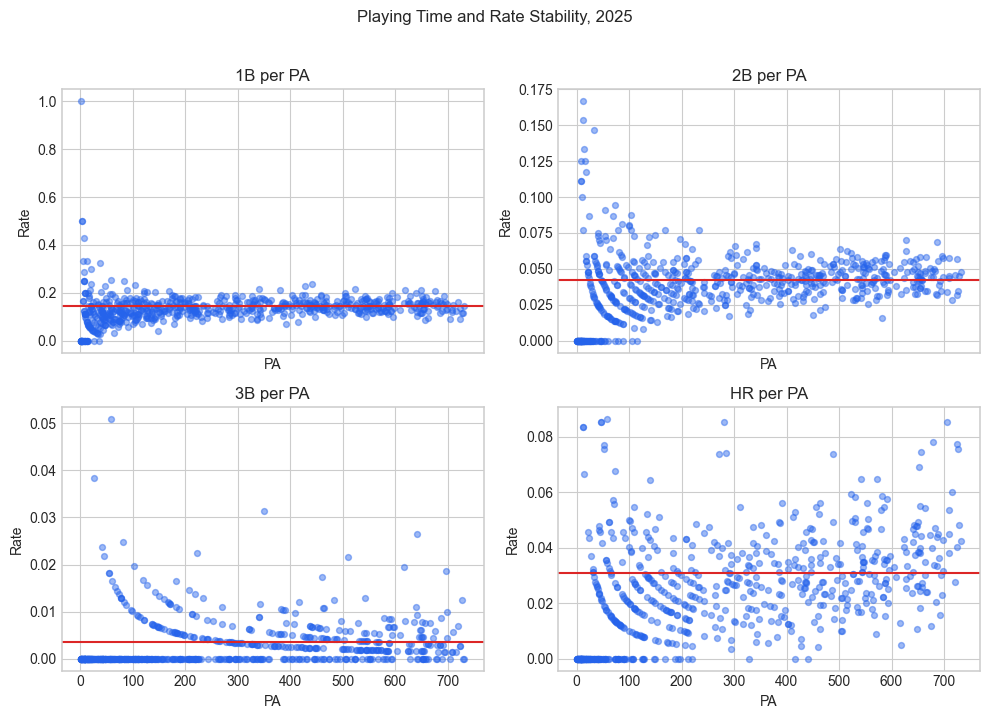

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axes = axes.ravel()

for axis, event, rate_column in zip(axes, events, rate_columns):
    axis.scatter(rates["PA"], rates[rate_column], s=18, alpha=0.45, color="#2563EB")
    axis.axhline(league_rates.loc[event, "event_per_PA"], color="#DC2626", linewidth=1.5)
    axis.set_title(f"{event} per PA")
    axis.set_xlabel("PA")
    axis.set_ylabel("Rate")

fig.suptitle(f"Playing Time and Rate Stability, {YEAR}", y=1.02)
fig.tight_layout()

## Compare Each Player to the League Rate

Subtracting the leaguewide rate gives a quick centered measure. Positive `per_PA_vs_lg` values mean the player produced that event more often than the league did per PA; positive `per_H_vs_lg` values mean that event made up a larger share of the player's hits than it did leaguewide.

In [17]:
for event in events:
    rates[f"{event}_per_PA_vs_lg"] = rates[f"{event}_per_PA"] - league_rates.loc[event, "event_per_PA"]
    rates[f"{event}_per_H_vs_lg"] = rates[f"{event}_per_H"] - league_hit_mix.loc[event, "share_of_hits"]

comparison_columns = [
    "Name",
    "Team",
    "PA",
    "H",
    *rate_columns,
    *hit_rate_columns,
    *[f"{event}_per_PA_vs_lg" for event in events],
    *[f"{event}_per_H_vs_lg" for event in events],
]
rates.loc[rates["PA"] >= MIN_PA_FOR_LEADERBOARDS, comparison_columns].head(10)

,Name,Team,PA,H,1B_per_PA,2B_per_PA,3B_per_PA,HR_per_PA,1B_per_H,2B_per_H,3B_per_H,HR_per_H,1B_per_PA_vs_lg,2B_per_PA_vs_lg,3B_per_PA_vs_lg,HR_per_PA_vs_lg,1B_per_H_vs_lg,2B_per_H_vs_lg,3B_per_H_vs_lg,HR_per_H_vs_lg
0,Francisco Lindor,NYM,732.0,172.0,0.144809,0.047814,0.000000,0.042350,0.616279,0.203488,0.000000,0.180233,0.002045,0.005474,-0.003433,0.011463,-0.034351,0.010529,-0.015646,0.039468
1,Rafael Devers,- - -,729.0,153.0,0.116598,0.045267,0.000000,0.048011,0.555556,0.215686,0.000000,0.228758,-0.026165,0.002928,-0.003433,0.017124,-0.095075,0.022727,-0.015646,0.087994
2,Shohei Ohtani,LAD,727.0,172.0,0.114168,0.034388,0.012380,0.075653,0.482558,0.145349,0.052326,0.319767,-0.028596,-0.007952,0.008947,0.044766,-0.168072,-0.047610,0.036680,0.179003
3,Matt Olson,ATL,724.0,170.0,0.135359,0.056630,0.002762,0.040055,0.576471,0.241176,0.011765,0.170588,-0.007404,0.014290,-0.000671,0.009168,-0.074160,0.048217,-0.003881,0.029824
4,Kyle Schwarber,PHI,724.0,145.0,0.088398,0.031768,0.002762,0.077348,0.441379,0.158621,0.013793,0.386207,-0.054366,-0.010572,-0.000671,0.046461,-0.209251,-0.034339,-0.001853,0.245443
5,Geraldo Perdomo,ARI,720.0,173.0,0.159722,0.045833,0.006944,0.027778,0.664740,0.190751,0.028902,0.115607,0.016959,0.003494,0.003511,-0.003109,0.014110,-0.002208,0.013256,-0.025157
6,Juan Soto,NYM,715.0,152.0,0.123077,0.027972,0.001399,0.060140,0.578947,0.131579,0.006579,0.282895,-0.019687,-0.014368,-0.002034,0.029253,-0.071683,-0.061380,-0.009067,0.142130
7,Julio Rodriguez,SEA,710.0,174.0,0.150704,0.043662,0.005634,0.045070,0.614943,0.178161,0.022989,0.183908,0.007941,0.001322,0.002201,0.014183,-0.035688,-0.014798,0.007342,0.043144
8,Pete Alonso,NYM,709.0,170.0,0.126939,0.057828,0.001410,0.053597,0.529412,0.241176,0.005882,0.223529,-0.015824,0.015488,-0.002023,0.022710,-0.121219,0.048217,-0.009764,0.082765
9,Randy Arozarena,SEA,709.0,146.0,0.121298,0.045134,0.001410,0.038082,0.589041,0.219178,0.006849,0.184932,-0.021466,0.002794,-0.002023,0.007195,-0.061589,0.026219,-0.008797,0.044167


## Multivariate Gaussian Check for Hit Mix

Now ignore triples and ask whether `1B_per_H`, `2B_per_H`, and `HR_per_H` look like one multivariate Gaussian cloud. This is a useful model check because a Gaussian fit would imply one smooth elliptical population, while strong departures can point to bounded rates, fat tails, or clustering among different hitter types.

We use the same minimum-hit pool as the hit-mix leaderboards. That keeps the diagnostic focused on players whose hit mix has enough observations to be interpretable.

In [18]:
gaussian_columns = ["1B_per_H", "2B_per_H", "HR_per_H"]
gaussian_pool = (
    rates.loc[
        rates["H"] >= MIN_H_FOR_LEADERBOARDS,
        ["Name", "Team", "PA", "H", *gaussian_columns],
    ]
    .dropna()
    .copy()
)

gaussian_pool.loc[:, ["PA", "H", *gaussian_columns]].describe()

,PA,H,1B_per_H,2B_per_H,HR_per_H
count,243.000000,243.000000,243.000000,243.000000,243.000000
mean,531.958848,122.004115,0.647921,0.191828,0.144422
std,106.899458,28.128762,0.078665,0.039532,0.067764
min,303.000000,75.000000,0.425373,0.077586,0.000000
25%,446.000000,99.000000,0.595033,0.165276,0.099174
50%,535.000000,119.000000,0.651899,0.189474,0.134831
75%,627.500000,145.000000,0.702430,0.222959,0.184857
max,732.000000,184.000000,0.865854,0.289474,0.408163


Fit the Gaussian by estimating the mean vector and covariance matrix from the player hit-mix data.

In [19]:
X = gaussian_pool.loc[:, gaussian_columns].to_numpy()
gaussian_mean = X.mean(axis=0)
gaussian_cov = np.cov(X, rowvar=False)
gaussian_inv_cov = np.linalg.pinv(gaussian_cov)

fit_summary = pd.DataFrame(
    {
        "mean": gaussian_mean,
        "std": np.sqrt(np.diag(gaussian_cov)),
    },
    index=gaussian_columns,
)

display(fit_summary)
display(pd.DataFrame(gaussian_cov, index=gaussian_columns, columns=gaussian_columns))

,mean,std
1B_per_H,0.647921,0.078665
2B_per_H,0.191828,0.039532
HR_per_H,0.144422,0.067764


,1B_per_H,2B_per_H,HR_per_H
1B_per_H,0.006188,-0.001504,-0.004410
2B_per_H,-0.001504,0.001563,-0.000095
HR_per_H,-0.004410,-0.000095,0.004592


A scatter-matrix view is the quickest visual check. One Gaussian should look like one roughly elliptical cloud in each two-dimensional projection.

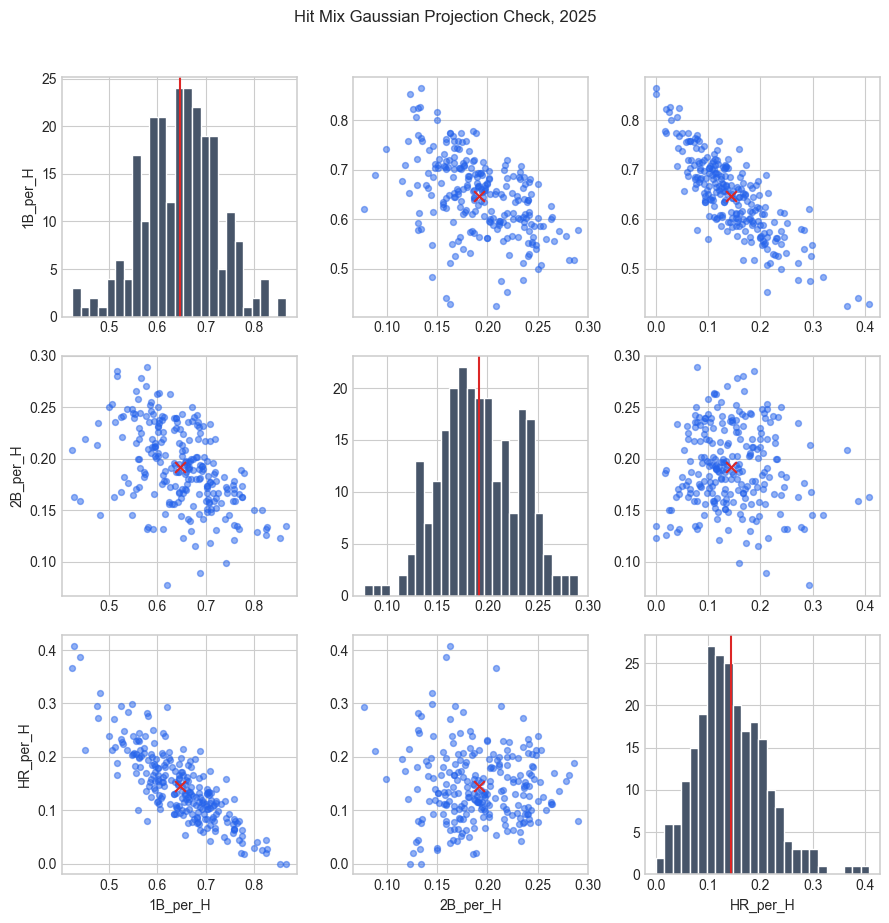

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for row_index, y_column in enumerate(gaussian_columns):
    for col_index, x_column in enumerate(gaussian_columns):
        axis = axes[row_index, col_index]

        if row_index == col_index:
            axis.hist(gaussian_pool[x_column], bins=25, color="#475569", edgecolor="white")
            axis.axvline(fit_summary.loc[x_column, "mean"], color="#DC2626", linewidth=1.5)
        else:
            axis.scatter(
                gaussian_pool[x_column],
                gaussian_pool[y_column],
                s=18,
                alpha=0.5,
                color="#2563EB",
            )
            axis.scatter(
                fit_summary.loc[x_column, "mean"],
                fit_summary.loc[y_column, "mean"],
                s=60,
                color="#DC2626",
                marker="x",
            )

        if row_index == len(gaussian_columns) - 1:
            axis.set_xlabel(x_column)
        if col_index == 0:
            axis.set_ylabel(y_column)

fig.suptitle(f"Hit Mix Gaussian Projection Check, {YEAR}", y=1.02)
fig.tight_layout()

Next, use Mahalanobis distance. If the fitted Gaussian is a good description, the ordered observed distances should fall inside the simulation envelope from the fitted Gaussian. Systematic bends or points outside the envelope suggest non-Gaussian tails, skew, or multiple groups.

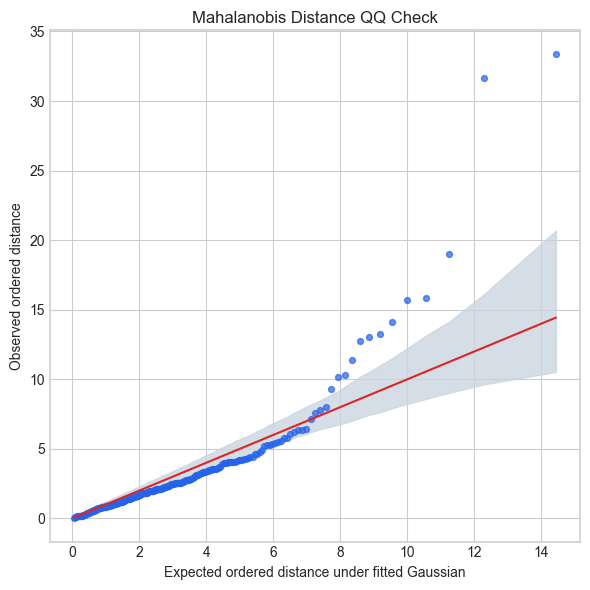

In [21]:
def squared_mahalanobis(values, mean, inv_cov):
    centered = values - mean
    return np.einsum("ij,jk,ik->i", centered, inv_cov, centered)


rng = np.random.default_rng(2025)
n_players, n_dimensions = X.shape
n_qq_simulations = 1_000

observed_d2 = squared_mahalanobis(X, gaussian_mean, gaussian_inv_cov)
simulated_sorted_d2 = np.empty((n_qq_simulations, n_players))

for simulation_index in range(n_qq_simulations):
    simulated = rng.multivariate_normal(gaussian_mean, gaussian_cov, size=n_players)
    simulated_d2 = squared_mahalanobis(simulated, gaussian_mean, gaussian_inv_cov)
    simulated_sorted_d2[simulation_index] = np.sort(simulated_d2)

observed_sorted_d2 = np.sort(observed_d2)
expected_sorted_d2 = simulated_sorted_d2.mean(axis=0)
lower_sorted_d2 = np.percentile(simulated_sorted_d2, 2.5, axis=0)
upper_sorted_d2 = np.percentile(simulated_sorted_d2, 97.5, axis=0)

fig, axis = plt.subplots(figsize=(6, 6))
axis.fill_between(expected_sorted_d2, lower_sorted_d2, upper_sorted_d2, color="#CBD5E1", alpha=0.8)
axis.scatter(expected_sorted_d2, observed_sorted_d2, s=18, alpha=0.7, color="#2563EB")
axis.plot(
    [expected_sorted_d2.min(), expected_sorted_d2.max()],
    [expected_sorted_d2.min(), expected_sorted_d2.max()],
    color="#DC2626",
    linewidth=1.5,
)
axis.set_title("Mahalanobis Distance QQ Check")
axis.set_xlabel("Expected ordered distance under fitted Gaussian")
axis.set_ylabel("Observed ordered distance")
fig.tight_layout()

Finally, compare a few scalar diagnostics with Gaussian simulations. Mardia skewness and kurtosis check multivariate shape; the tail-share diagnostic asks whether too many players are far from the fitted center; nearest-neighbor diagnostics are a lightweight way to flag local clumping.

In [22]:
def mardia_diagnostics(values):
    mean = values.mean(axis=0)
    cov = np.cov(values, rowvar=False)
    inv_cov = np.linalg.pinv(cov)
    centered = values - mean
    inner = centered @ inv_cov @ centered.T
    d2 = np.diag(inner)

    return {
        "mardia_skewness": np.mean(inner**3),
        "mardia_kurtosis": np.mean(d2**2),
    }


def nearest_neighbor_distances(values):
    diff = values[:, None, :] - values[None, :, :]
    distances = np.sqrt(np.sum(diff**2, axis=2))
    np.fill_diagonal(distances, np.inf)
    return distances.min(axis=1)


eigvals, eigvecs = np.linalg.eigh(gaussian_cov)
eigvals = np.clip(eigvals, 1e-12, None)
whitening = eigvecs @ np.diag(1 / np.sqrt(eigvals)) @ eigvecs.T

reference = rng.multivariate_normal(gaussian_mean, gaussian_cov, size=20_000)
reference_d2_95 = np.percentile(
    squared_mahalanobis(reference, gaussian_mean, gaussian_inv_cov),
    95,
)

observed_whitened = (X - gaussian_mean) @ whitening
observed_nn = nearest_neighbor_distances(observed_whitened)
observed_diagnostics = {
    **mardia_diagnostics(X),
    "share_beyond_gaussian_95": np.mean(observed_d2 > reference_d2_95),
    "max_mahalanobis_sq": observed_d2.max(),
    "mean_nearest_neighbor": observed_nn.mean(),
    "cv_nearest_neighbor": observed_nn.std(ddof=1) / observed_nn.mean(),
}

n_diagnostic_simulations = 500
simulated_diagnostics = []

for simulation_index in range(n_diagnostic_simulations):
    simulated = rng.multivariate_normal(gaussian_mean, gaussian_cov, size=n_players)
    simulated_d2 = squared_mahalanobis(simulated, gaussian_mean, gaussian_inv_cov)
    simulated_whitened = (simulated - gaussian_mean) @ whitening
    simulated_nn = nearest_neighbor_distances(simulated_whitened)

    simulated_diagnostics.append(
        {
            **mardia_diagnostics(simulated),
            "share_beyond_gaussian_95": np.mean(simulated_d2 > reference_d2_95),
            "max_mahalanobis_sq": simulated_d2.max(),
            "mean_nearest_neighbor": simulated_nn.mean(),
            "cv_nearest_neighbor": simulated_nn.std(ddof=1) / simulated_nn.mean(),
        }
    )

simulated_diagnostics = pd.DataFrame(simulated_diagnostics)

diagnostic_rows = []
for diagnostic_name, observed_value in observed_diagnostics.items():
    simulated_values = simulated_diagnostics[diagnostic_name]
    p_low = (simulated_values <= observed_value).mean()
    p_high = (simulated_values >= observed_value).mean()
    diagnostic_rows.append(
        {
            "diagnostic": diagnostic_name,
            "observed": observed_value,
            "gaussian_sim_mean": simulated_values.mean(),
            "gaussian_sim_p05": simulated_values.quantile(0.05),
            "gaussian_sim_p95": simulated_values.quantile(0.95),
            "gaussian_tail_probability": min(1, 2 * min(p_low, p_high)),
        }
    )

diagnostic_summary = pd.DataFrame(diagnostic_rows).set_index("diagnostic")
diagnostic_summary

,observed,gaussian_sim_mean,gaussian_sim_p05,gaussian_sim_p95,gaussian_tail_probability
diagnostic,,,,,
mardia_skewness,6.880484,0.237544,0.085147,0.462457,0.000
mardia_kurtosis,24.271865,14.749166,13.688314,15.910372,0.000
share_beyond_gaussian_95,0.061728,0.050025,0.028807,0.070165,0.448
max_mahalanobis_sq,33.410290,14.603092,11.014670,20.159363,0.000
mean_nearest_neighbor,0.346845,0.389634,0.363584,0.414788,0.004
cv_nearest_neighbor,0.807296,0.589726,0.518843,0.669263,0.000


In [23]:
flagged_diagnostics = diagnostic_summary.loc[
    diagnostic_summary["gaussian_tail_probability"] < 0.05
]

if flagged_diagnostics.empty:
    print(
        "These diagnostics do not strongly reject a single Gaussian description "
        "for this minimum-hit pool. Still check the projection and QQ plots."
    )
else:
    print("Diagnostics with unusually non-Gaussian values under the fitted Gaussian simulation:")
    display(flagged_diagnostics)
    print(
        "This points toward non-Gaussian structure such as skew, heavy tails, "
        "bounded/compositional rates, or clustering among hitter types."
    )

Diagnostics with unusually non-Gaussian values under the fitted Gaussian simulation:


,observed,gaussian_sim_mean,gaussian_sim_p05,gaussian_sim_p95,gaussian_tail_probability
diagnostic,,,,,
mardia_skewness,6.880484,0.237544,0.085147,0.462457,0.000
mardia_kurtosis,24.271865,14.749166,13.688314,15.910372,0.000
max_mahalanobis_sq,33.410290,14.603092,11.014670,20.159363,0.000
mean_nearest_neighbor,0.346845,0.389634,0.363584,0.414788,0.004
cv_nearest_neighbor,0.807296,0.589726,0.518843,0.669263,0.000


This points toward non-Gaussian structure such as skew, heavy tails, bounded/compositional rates, or clustering among hitter types.


## Notes

- `1B / PA`, `2B / PA`, `3B / PA`, and `HR / PA` are opportunity rates; they describe how often each event happened per plate appearance.
- `1B / H`, `2B / H`, `3B / H`, and `HR / H` are hit-mix rates; they describe what kinds of hits a player produced after recording a hit.
- The all-player dataset is useful for understanding the full population, but leaderboard claims should usually use a PA cutoff.
- Leaguewide rates should be calculated from summed events over summed denominators, not by taking the unweighted average of player rates.
- A natural next step is to repeat this for multiple seasons and ask whether player rates stabilize differently for singles, doubles, triples, and home runs.

In [24]:
BODF = pd.read_csv('https://raw.githubusercontent.com/fantasy-toolz/batting-order/refs/heads/main/data/Aggregate/Summaries/2025player-batting-order.csv')

In [25]:
cleanup_threshold = 20.
cleanup = list(BODF['player'][BODF['b4'] > cleanup_threshold].values)
print("Players with more than 20G batting cleanup:",cleanup)

Players with more than 20G batting cleanup: ['Taylor Ward', 'Jorge Soler', 'Jo Adell', 'Christian Walker', 'Yainer Diaz', 'Carlos Correa', 'Brent Rooker', 'Shea Langeliers', 'Miguel Andujar', 'Tyler Soderstrom', 'Bo Bichette', 'Alejandro Kirk', 'George Springer', 'Addison Barger', 'Matt Olson', 'Marcell Ozuna', 'Drake Baldwin', 'Christian Yelich', 'William Contreras', 'Andrew Vaughn', 'Willson Contreras', 'Nolan Arenado', 'Michael Busch', 'Pete Crow-Armstrong', 'Carson Kelly', 'Carlos Santana', 'Lourdes Gurriel Jr.', 'Josh Naylor', 'Eugenio Suarez', 'Teoscar Hernandez', 'Will Smith', 'Freddie Freeman', 'Matt Chapman', 'Wilmer Flores', 'Dominic Smith', 'Kyle Manzardo', 'David Fry', 'Cal Raleigh', 'Randy Arozarena', 'Jorge Polanco', 'Kyle Stowers', 'Otto Lopez', 'Liam Hicks', 'Agustin Ramirez', 'Pete Alonso', 'Brandon Nimmo', 'Josh Bell', 'Nathaniel Lowe', 'Keibert Ruiz', 'Daylen Lile', 'Adley Rutschman', "Ryan O'Hearn", 'Ryan Mountcastle', 'Xander Bogaerts', 'Jackson Merrill', 'Gavin Sh

Matched cleanup players with hit-mix rates: 86


,cleanup_name,Name,Team,PA,H,1B_per_H,2B_per_H,HR_per_H
0,Matt Olson,Matt Olson,ATL,724.0,170.0,0.576471,0.241176,0.170588
1,Kyle Schwarber,Kyle Schwarber,PHI,724.0,145.0,0.441379,0.158621,0.386207
2,Pete Alonso,Pete Alonso,NYM,709.0,170.0,0.529412,0.241176,0.223529
3,Randy Arozarena,Randy Arozarena,SEA,709.0,146.0,0.589041,0.219178,0.184932
4,Cal Raleigh,Cal Raleigh,SEA,705.0,147.0,0.428571,0.163265,0.408163
5,Brent Rooker,Brent Rooker,ATH,699.0,164.0,0.554878,0.243902,0.182927
6,Vinnie Pasquantino,Vinnie Pasquantino,KCR,682.0,164.0,0.597561,0.201220,0.195122
7,Maikel Garcia,Maikel Garcia,KCR,666.0,170.0,0.647059,0.229412,0.094118
8,Taylor Ward,Taylor Ward,LAA,663.0,132.0,0.477273,0.234848,0.272727
9,William Contreras,William Contreras,MIL,659.0,147.0,0.693878,0.190476,0.115646


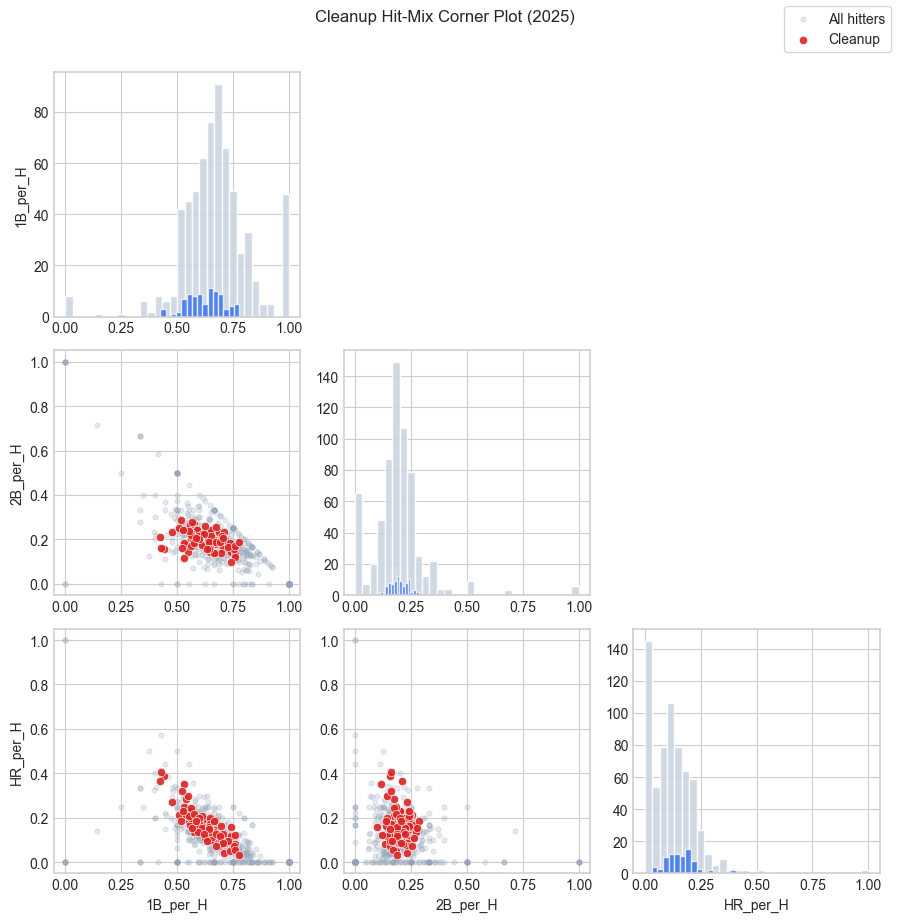

In [26]:
# Crossmatch cleanup names with FanGraphs rates
plot_cols = ["1B_per_H", "2B_per_H", "HR_per_H"]

cleanup_df = pd.DataFrame({"cleanup_name": cleanup}).dropna()
cleanup_df["name_key"] = cleanup_df["cleanup_name"].astype(str).str.strip().str.lower()

rates_match = rates.loc[:, ["Name", "Team", "PA", "H", *plot_cols]].copy()
rates_match["name_key"] = rates_match["Name"].astype(str).str.strip().str.lower()

cleanup_rates = (
    cleanup_df.merge(rates_match, on="name_key", how="left")
    .drop(columns=["name_key"])
    .sort_values(["PA", "H"], ascending=False)
    .reset_index(drop=True)
)

missing_cleanup = cleanup_rates.loc[cleanup_rates["Name"].isna(), "cleanup_name"].tolist()
if missing_cleanup:
    print(f"No Fangraphs match for {len(missing_cleanup)} cleanup names:")
    print(missing_cleanup)

cleanup_rates_matched = cleanup_rates.dropna(subset=plot_cols).copy()
print(f"Matched cleanup players with hit-mix rates: {len(cleanup_rates_matched)}")
display(cleanup_rates_matched.loc[:, ["cleanup_name", "Name", "Team", "PA", "H", *plot_cols]].head(20))

# Corner scatter plot (lower-triangle) for cleanup players vs all hitters with H > 0
background = rates.loc[rates["H"] > 0, plot_cols].dropna()

fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for i, y_col in enumerate(plot_cols):
    for j, x_col in enumerate(plot_cols):
        ax = axes[i, j]

        if j > i:
            ax.axis("off")
            continue

        if i == j:
            ax.hist(background[x_col], bins=30, color="#CBD5E1", edgecolor="white", alpha=0.9, label="All hitters")
            ax.hist(cleanup_rates_matched[x_col], bins=15, color="#2563EB", edgecolor="white", alpha=0.75, label="Cleanup")
        else:
            ax.scatter(background[x_col], background[y_col], s=12, alpha=0.22, color="#94A3B8", label="All hitters")
            ax.scatter(
                cleanup_rates_matched[x_col],
                cleanup_rates_matched[y_col],
                s=36,
                alpha=0.9,
                color="#DC2626",
                edgecolor="white",
                linewidth=0.5,
                label="Cleanup",
            )

        if i == len(plot_cols) - 1:
            ax.set_xlabel(x_col)
        else:
            ax.set_xlabel("")

        if j == 0:
            ax.set_ylabel(y_col)
        else:
            ax.set_ylabel("")

# Single legend
handles, labels = axes[2, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles[:2], labels[:2], loc="upper right", frameon=True)

fig.suptitle(f"Cleanup Hit-Mix Corner Plot ({YEAR})", y=1.02)
fig.tight_layout()